In [1]:
from IPython.display import display, HTML

display(HTML(r"""
<style>
/* JupyterLab 4.x: center the notebook area */
.jp-NotebookPanel-notebook,
.jp-NotebookPanel .jp-Notebook {
  width: 85% !important;
  max-width: 1100px !important;
  margin: 0 auto !important;
}


/* Make wide outputs scroll instead of breaking the layout */
.jp-OutputArea-output {
  overflow-x: auto !important;
}
</style>
"""))

%config InlineBackend.figure_format = "svg"
print("Centered JupyterLab notebook + SVG inline figures.")

Centered JupyterLab notebook + SVG inline figures.


## 1. Naive Bayes for mini-newsgroups

In [2]:
import os
import spacy
import string
import numpy as np
from spacy.lang.en.stop_words import STOP_WORDS
import matplotlib.pyplot as plt
from sklearn import model_selection
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

In [4]:
# unzip the datasets.zip file, you will find there are some datasets (20_newsgroups, acllmdb, mini_newsgroups)
X = [] # an element of X is represented as (filename, text)
Y = [] # an element of Y represents the newsgroup category of the corresponding X element
for category in os.listdir('.datasets/mini_newsgroups'):
    if category.startswith('.'): 
        continue
    for document in os.listdir('.datasets/mini_newsgroups/'+category):
        if document.startswith('.'): 
            continue
        with open('.datasets/mini_newsgroups/'+category+'/'+document, "r", errors='ignore') as f:
            X.append((document,f.read()))
            Y.append(category)
print(len(X), len(Y))
print(X[0]) # first training sammple
print(Y[0]) # first training label

2000 2000
('75895', 'Newsgroups: talk.politics.mideast\nPath: cantaloupe.srv.cs.cmu.edu!crabapple.srv.cs.cmu.edu!bb3.andrew.cmu.edu!news.sei.cmu.edu!cis.ohio-state.edu!zaphod.mps.ohio-state.edu!cs.utexas.edu!uunet!brunix!doorknob!hm\nFrom: hm@cs.brown.edu (Harry Mamaysky)\nSubject: Heil Hernlem \nIn-Reply-To: hernlem@chess.ncsu.edu\'s message of Wed, 14 Apr 1993 12:58:13 GMT\nMessage-ID: <HM.93Apr15112701@yoda.cs.brown.edu>\nSender: news@cs.brown.edu\nOrganization: Dept. of Computer Science, Brown University\nReferences: <1993Apr14.125813.21737@ncsu.edu>\nDate: Thu, 15 Apr 1993 16:27:01 GMT\nLines: 24\n\nIn article <1993Apr14.125813.21737@ncsu.edu> hernlem@chess.ncsu.edu (Brad Hernlem) writes:\n\n   Lebanese resistance forces detonated a bomb under an Israeli occupation\n   patrol in Lebanese territory two days ago. Three soldiers were killed and\n   two wounded. In "retaliation", Israeli and Israeli-backed forces wounded\n   8 civilians by bombarding several Lebanese villages. Ironica

In [ ]:
# Task 1: use model_selection.train_test_split function 
# to split your data X and Y into train and test

X_train, X_test, Y_train, Y_test = \
model_selection.train_test_split(X, Y, test_size=0.25, random_state=0)

In [9]:
A=[1,2,3,4,5,6]
B=['a','b','c','d','e','f']
A_train,A_test,B_train,B_test=model_selection.train_test_split(A,B,test_size=0.33)
print(A_train)
print(B_train)


[3, 1, 2, 5]
['c', 'a', 'b', 'e']


In [20]:
# Task 2: build a vocabulary of words (you may remove stop words and do some preprocessing)
# for example, if the frequency of some words less than <= 5, then just ignore them.
# so that you can have a lower dimension for your feature vectors.
nlp = spacy.load('en_core_web_sm')
# Building a vocabulary of words from the given documents
vocab = {}
for i in range(len(X_train)):
    for word in X_train[i][1].split():
        word_new = word.strip(string.punctuation).lower()
        if (len(word_new) > 2) and (word_new not in STOP_WORDS):
            if word_new in vocab:
                vocab[word_new] += 1
            else:
                vocab[word_new] = 1
cutoff_freq = 5
num_words_above_cutoff = \
sum(1 for word in vocab if vocab[word] >= cutoff_freq)
print("Number of words with frequency higher than cutoff frequency ({}) :"\
    .format(cutoff_freq), num_words_above_cutoff)
features = []
for key in vocab:
    if vocab[key] >= cutoff_freq:
        features.append(key)
for i in range(10):
    print(features[i])

Number of words with frequency higher than cutoff frequency (5) : 7363
newsgroups
rec.motorcycles
path
sterling
subject
wing
message-id
sender
usenet@wam.umd.edu
usenet


In [32]:
# Task 3: to represent training and testing data as word vector counts
X_train_dataset = np.zeros((len(X_train),len(features)))
word_to_idx = {word: i for i, word in enumerate(features)}
# This can take some time to complete
for i in range(len(X_train)):
    # print(i) # Uncomment to see progress
    word_list = [ word.strip(string.punctuation).lower() for word in X_train[i][1].split()]
    for word in word_list:
        if word in word_to_idx:
            X_train_dataset[i][word_to_idx[word]] += 1

In [31]:
# To represent test data as word vector counts
X_test_dataset = np.zeros((len(X_test),len(features)))
# This can take some time to complete
for i in range(len(X_test)):
    # print(i) # Uncomment to see progress
    word_list = [ word.strip(string.punctuation).lower() for word in X_test[i][1].split()]
    for word in word_list:
        if word in word_to_idx:
            X_test_dataset[i][word_to_idx[word]] += 1

In [39]:
# Task 4: using sklearn's Multinomial Naive Bayes class: MultinomialNB to do classification
# you may use predict() and score function to test your model on testing datasets.
clf = MultinomialNB()
clf.fit(X_train_dataset,Y_train)
Y_test_pred = clf.predict(X_test_dataset)
sklearn_score_train = clf.score(X_train_dataset,Y_train)
print("Sklearn's score on training data :",sklearn_score_train)
sklearn_score_test = clf.score(X_test_dataset,Y_test)
print("Sklearn's score on testing data :",sklearn_score_test)
print("Classification report for testing data :-")
print(classification_report(Y_test, Y_test_pred))

Sklearn's score on training data : 0.974
Sklearn's score on testing data : 0.804
Classification report for testing data :-
                          precision    recall  f1-score   support

             alt.atheism       0.68      0.77      0.72        22
           comp.graphics       0.67      0.64      0.65        25
 comp.os.ms-windows.misc       0.71      0.59      0.64        29
comp.sys.ibm.pc.hardware       0.54      0.88      0.67        25
   comp.sys.mac.hardware       0.88      0.88      0.88        32
          comp.windows.x       0.94      0.57      0.71        28
            misc.forsale       0.84      0.91      0.88        23
               rec.autos       0.69      0.86      0.77        21
         rec.motorcycles       0.95      1.00      0.98        20
      rec.sport.baseball       0.93      0.96      0.94        26
        rec.sport.hockey       1.00      1.00      1.00        23
               sci.crypt       1.00      0.96      0.98        25
         sci.elect

## 2. Logistic Regression for IMDB datasets

In [40]:
import re
import pickle
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegressionCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

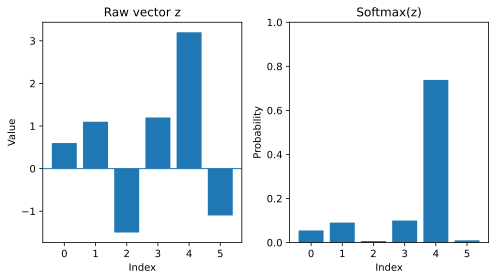

z = [ 0.6  1.1 -1.5  1.2  3.2 -1.1]
softmax(z) = [0.05482541 0.09039182 0.00671372 0.09989841 0.73815494 0.0100157 ]
sum of softmax = 0.9999999999999999


In [41]:
import numpy as np
import matplotlib.pyplot as plt

z = np.array([0.6, 1.1, -1.5, 1.2, 3.2, -1.1])

def softmax(x):
    x_shifted = x - np.max(x)   # for numerical stability
    exp_x = np.exp(x_shifted)
    return exp_x / np.sum(exp_x)

p = softmax(z)

indices = np.arange(len(z))

fig, axes = plt.subplots(1, 2, figsize=(7, 4))

# Left: raw z vector
axes[0].bar(indices, z)
axes[0].axhline(0, linewidth=1)
axes[0].set_xticks(indices)
axes[0].set_xlabel("Index")
axes[0].set_ylabel("Value")
axes[0].set_title("Raw vector z")

# Right: softmax probabilities
axes[1].bar(indices, p)
axes[1].set_xticks(indices)
axes[1].set_xlabel("Index")
axes[1].set_ylabel("Probability")
axes[1].set_title("Softmax(z)")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("z =", z)
print("softmax(z) =", p)
print("sum of softmax =", p.sum())

In [48]:
df = pd.read_csv('.datasets/IMDB-Dataset.csv')
df.head(5)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [43]:
def preprocessor(text):
    text = re.sub(r'<[^>]*>', '', text)
    emoticons = re.findall(r'(?::|;|=)(?:-)?(?:\)|\(|D|P)', text)
    text = re.sub(r'[\W]+', ' ', text.lower()) + ' '.join(emoticons).replace('-', '')
    return text

df['review'] = df['review'].apply(preprocessor)
df.head(5)

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there s a family where a little boy ...,negative
4,petter mattei s love in the time of money is a...,positive


In [49]:
# prepare some training and testing samples

num_samples = len(df['review'])
num_train = int(num_samples * 0.7)
num_test = int(num_samples * 0.3)
random_indices = np.random.permutation(num_samples)

In [50]:
# Task 1: make trainng and testing datasets

X_train = df.loc[random_indices[:num_train], 'review'].values
y_train = df.loc[random_indices[:num_train], 'sentiment'].values
X_test = df.loc[random_indices[-num_test:], 'review'].values
y_test = df.loc[random_indices[-num_test:], 'sentiment'].values

In [51]:
print("X_train : ",X_train.shape," X_test : ",X_test.shape, 
      "\ny_train : ",y_train.shape," y_test : ",y_test.shape)

X_train :  (35000,)  X_test :  (15000,) 
y_train :  (35000,)  y_test :  (15000,)


In [52]:
# Task 2: Use TF-IDF matrix to as input features

# Your code be something like
tfidf = TfidfVectorizer()
classifier = LogisticRegressionCV(
    max_iter = 1000,
    cv=5,
    scoring='accuracy',
    l1_ratios=(0.0,),
    solver='lbfgs',
    use_legacy_attributes=False)
clf = Pipeline([
    ('tfidf',tfidf), 
    ('clf',classifier)
])
clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [53]:
# make some predictions and explore it
y_pred = clf.predict(X_test)

In [54]:
# Task 3: make prediction on testing datasets

y_pred = clf.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(print(classification_report(y_test, y_pred)))
print(accuracy_score(y_test, y_pred))

[[6618  827]
 [ 733 6822]]
              precision    recall  f1-score   support

    negative       0.90      0.89      0.89      7445
    positive       0.89      0.90      0.90      7555

    accuracy                           0.90     15000
   macro avg       0.90      0.90      0.90     15000
weighted avg       0.90      0.90      0.90     15000

None
0.896


## 3. Train word2vec using gensim

In this demo code, you will see how to use gensim to train a word2vec model.

**Install gensim via:**
```shell
conda install anaconda::gensim
conda install anaconda::scikit-learn
```
**The following demo code follows: [word2vec]**(https://radimrehurek.com/gensim/models/word2vec.html)

In [55]:
import random
import tempfile
import numpy as np  
import matplotlib.pyplot as plt

import gensim.models
from gensim import utils
from gensim.test.utils import datapath
from sklearn.decomposition import IncrementalPCA    # inital reduction
from sklearn.manifold import TSNE                   # final reduction

In [56]:
# Assume there's one document per line, tokens separated by whitespace
corpus_path = datapath('lee_background.cor')
for ind, line in enumerate(open(corpus_path)):
    print(ind, line[0:100])
    if ind > 10:
        break

0 Hundreds of people have been forced to vacate their homes in the Southern Highlands of New South Wal
1 Indian security forces have shot dead eight suspected militants in a night-long encounter in souther
2 The national road toll for the Christmas-New Year holiday period stands at 45, eight fewer than for 
3 Argentina's political and economic crisis has deepened with the resignation of its interim President
4 Six midwives have been suspended at Wollongong Hospital, south of Sydney, for inappropriate use of n
5 The Federal Government says it should be safe for Afghani asylum seekers in Australia to return home
6 The United States team of Monica Seles and Jan-Michael Gambill scored a decisive victory over unseed
7 Hundreds of canoeists are enjoying hard-earned New Years Eve celebrations following five days paddli
8 There has been welcome relief for firefighters in New South Wales overnight with milder weather allo
9 Some roads are closed because of dangerous conditions caused by bushfir

In [57]:
### Build corpus
class MyCorpus:
    """An iterator that yields sentences (lists of str)."""
    def __iter__(self):
        corpus_path = datapath('lee_background.cor')
        for line in open(corpus_path):
            # assume there's one document per line, tokens separated by whitespace
            yield utils.simple_preprocess(line)

- **Training word2vec model**

In [58]:
# get list of sentences
sentences = MyCorpus()
model = gensim.models.Word2Vec(
    sentences=sentences, vector_size=100, alpha=0.025, window=5, 
    min_count=5, sample=0.001, seed=1, workers=3, min_alpha=0.0001, 
    sg=1, negative=5, ns_exponent=0.75, epochs=5, sorted_vocab=1)

In [60]:
vec_king = model.wv['king']
print(vec_king)
for index, word in enumerate(model.wv.index_to_key):
    if index == 10:
        break
    print(f"word #{index}/{len(model.wv.index_to_key)} is {word}")

[-6.72696605e-02  2.21390083e-01 -2.94854809e-02 -4.10365649e-02
  1.04479440e-01 -2.34634936e-01  6.63564056e-02  3.73098791e-01
 -5.56262359e-02  4.44316026e-03  2.36709584e-02 -1.94850743e-01
  1.19644582e-01  9.50763840e-03  8.77385810e-02 -7.55703598e-02
  8.17474499e-02 -1.36849999e-01 -9.81796458e-02 -3.04852247e-01
  1.68993667e-01  6.12866506e-02  1.40716448e-01 -1.35393227e-02
 -8.19491595e-02 -2.80048195e-02 -6.14397824e-02  2.15539336e-02
 -1.41289562e-01 -1.06125481e-01  1.51176557e-01 -1.40481517e-01
  1.35423794e-01 -1.39644891e-01 -8.17113519e-02  1.10635318e-01
  1.44462571e-01 -1.05628088e-01 -4.66101989e-02 -1.43775836e-01
  1.08078524e-01 -7.08286986e-02 -1.03792951e-01 -8.78675878e-02
  3.05248518e-03  1.13309333e-02 -1.69834420e-01  6.07688949e-02
  1.02992065e-01  1.23605400e-01  5.65272495e-02 -5.85365593e-02
 -1.09102584e-01 -8.87300819e-02 -1.50901387e-02 -2.27985587e-02
  1.02546617e-01 -7.41623640e-02 -1.52765632e-01  5.15551418e-02
 -8.94867778e-02  4.21910

- **Storing and loading models**

In [61]:
with tempfile.NamedTemporaryFile(prefix='gensim-model-', delete=False) as tmp:
    temporary_filepath = tmp.name
    model.save(temporary_filepath)
    # The model is now safely stored in the filepath.
    # You can copy it to other machines, share it with others, etc.
    # To load a saved model:
    new_model = gensim.models.Word2Vec.load(temporary_filepath)

In [62]:
model = gensim.models.Word2Vec.load(temporary_filepath)
more_sentences = [
    ['Advanced', 'users', 'can', 'load', 'a', 'model',
     'and', 'continue', 'training', 'it', 'with', 'more', 'sentences'],]
model.build_vocab(more_sentences, update=True)
model.train(more_sentences, total_examples=model.corpus_count, epochs=model.epochs)

# cleaning up temporary file
import os
os.remove(temporary_filepath)

- **Visualising Word Embeddings using t-SNE**

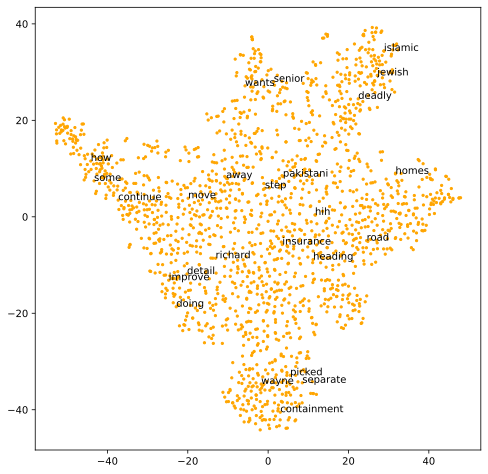

In [63]:
def reduce_dimensions(model):
    num_dimensions = 2  # final num dimensions (2D, 3D, etc)
    # extract the words & their vectors, as numpy arrays
    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)  # fixed-width numpy strings
    # reduce using t-SNE
    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)
    x_vals = [v[0] for v in vectors]
    y_vals = [v[1] for v in vectors]
    return x_vals, y_vals, labels

x_vals, y_vals, labels = reduce_dimensions(model)

def plot_with_matplotlib(x_vals, y_vals, labels):
    random.seed(0)
    plt.figure(figsize=(8, 8))
    plt.scatter(x_vals, y_vals, s = 5, color= 'orange')
    #
    # Label randomly subsampled 25 data points
    #
    indices = list(range(len(labels)))
    selected_indices = random.sample(indices, 25)
    for i in selected_indices:
        plt.annotate(labels[i], (x_vals[i], y_vals[i]))
        
plot_with_matplotlib(x_vals, y_vals, labels)

## 4. Exploring Qwen embeddings

In [64]:
# Requires transformers>=4.51.0

import torch
import torch.nn.functional as F

from torch import Tensor
from transformers import AutoTokenizer, AutoModel

In [ ]:
def last_token_pool(last_hidden_states: Tensor,
                 attention_mask: Tensor) -> Tensor:
    left_padding = (attention_mask[:, -1].sum() == attention_mask.shape[0])
    if left_padding:
        return last_hidden_states[:, -1]
    else:
        sequence_lengths = attention_mask.sum(dim=1) - 1
        batch_size = last_hidden_states.shape[0]
        return last_hidden_states[torch.arange(batch_size, device=last_hidden_states.device), sequence_lengths]


def get_detailed_instruct(task_description: str, query: str) -> str:
    return f'Instruct: {task_description}\nQuery:{query}'

In [66]:
import os
print(os.environ.get("HF_ENDPOINT"))

None


In [67]:
# Each query must come with a one-sentence instruction that describes the task
task = 'Given a web search query, retrieve relevant passages that answer the query'

# We have two queries:
queries = [
    get_detailed_instruct(task, 'What is the capital of China?'),
    get_detailed_instruct(task, 'Explain gravity')
]

# No need to add instruction for retrieval documents
# We have two documents
documents = [
    "The capital of China is Beijing.",
    "Gravity is a force that attracts two bodies towards each other. \
    It gives weight to physical objects and is responsible for \
    the movement of planets around the sun."
    ]
input_texts = queries + documents

tokenizer = AutoTokenizer.from_pretrained(
    'Qwen/Qwen3-Embedding-0.6B', 
    padding_side='left')
model = AutoModel.from_pretrained(
    'Qwen/Qwen3-Embedding-0.6B')

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

In [68]:
# We recommend enabling flash_attention_2 for 
# better acceleration and memory saving.
# model = AutoModel.from_pretrained('Qwen/Qwen3-Embedding-0.6B', 
# attn_implementation="flash_attention_2", 
# torch_dtype=torch.float16).cuda()
max_length = 8192

# Tokenize the input texts
batch_dict = tokenizer(
    input_texts,
    padding=True,
    truncation=True,
    max_length=max_length,
    return_tensors="pt",
)
batch_dict.to(model.device)
with torch.no_grad():
    outputs = model(**batch_dict)
    # with rows corresponding to:
    # embeddings[0] = query 1
    # embeddings[1] = query 2
    # embeddings[2] = document 1
    # embeddings[3] = document 2
    embeddings = last_token_pool(
        outputs.last_hidden_state, 
        batch_dict['attention_mask'])
    # normalize embeddings: makes each embedding have unit length.
    embeddings = F.normalize(embeddings, p=2, dim=1)
    # embeddings[:2] = the 2 query embeddings
    # embeddings[2:] = the 2 document embeddings
    scores = (embeddings[:2] @ embeddings[2:].T)
    
print(scores.tolist())
# [[0.7645568251609802, 0.14142508804798126], 
# [0.13549736142158508, 0.5999549627304077]]

[[0.765625, 0.1533203125], [0.1357421875, 0.69140625]]


- Query 1 = "What is the capital of China?"
- Query 2 = "Explain gravity"
- Document 1 = "The capital of China is Beijing."
- Document 2 = "Gravity is a force that attracts two bodies ..."
Then the matrix means:

\begin{bmatrix}
\text{sim}(Q1,D1) & \text{sim}(Q1,D2) \\
\text{sim}(Q2,D1) & \text{sim}(Q2,D2)
\end{bmatrix}

So the 4 scores are (these scores make sense):

1. 0.7646: Similarity between Query 1 and Document 1
2. 0.1515 Similarity between: Query 1 and Document 2
3. 0.1354 Similarity between: Query 2 and Document 1
4. 0.6931 Similarity between: Query 2 and Document 2

## 5. Exploring Google embeddinggemma

In [71]:
import ollama
import numpy as np

task = "Given a web search query, retrieve relevant passages that answer the query"

def get_detailed_instruct(task_description: str, query: str) -> str:
    return f"Instruct: {task_description}\nQuery: {query}"

queries = [
    get_detailed_instruct(task, "What is the capital of China?"),
    get_detailed_instruct(task, "Explain gravity"),
]

documents = [
    "The capital of China is Beijing.",
    "Gravity is a force that attracts two bodies towards each other. "
    "It gives weight to physical objects and is responsible for "
    "the movement of planets around the sun."
]

def embed_one(text):
    response = ollama.embed(
        model="embeddinggemma",
        input=text,
    )
    return np.array(response.embeddings[0], dtype=np.float32)

query_embs = np.stack([embed_one(q) for q in queries], axis=0)
doc_embs = np.stack([embed_one(d) for d in documents], axis=0)

# normalize so dot product becomes cosine similarity
query_embs = query_embs / np.linalg.norm(query_embs, axis=1, keepdims=True)
doc_embs = doc_embs / np.linalg.norm(doc_embs, axis=1, keepdims=True)

scores = query_embs @ doc_embs.T

print(scores)

[[0.62283915 0.19101278]
 [0.19518155 0.44142124]]


In [33]:
!jupyter nbconvert lecture-03-embeddings.ipynb --to html --template classic --embed-images

[NbConvertApp] Converting notebook lecture-03-embeddings.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 715538 bytes to lecture-03-embeddings.html
